## Test mask exploration #1

Ce notebook teste la creation des masques pour detecter les sections avec/sans chant d'oiseau

In [1]:
# assure le reload de src si modifications sont faite

%load_ext autoreload
%autoreload 2

In [2]:
# import utilitaires

%matplotlib inline

import librosa as rosa
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import webrtcvad as wrtc

from copy import deepcopy
from IPython.display import Audio
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA as sk_PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

In [3]:
# import package develope pour le projet

import ffury

from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)
from ffury.optional.development.dataset import IndexedDataset
from ffury.transforms import spectrogram_from_audio
from ffury.optional.development.misc.hdf5 import open_file
from ffury.optional.development.transforms.properties import _SPECTROGRAM


def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

In [4]:
# load datasets
# dataset_train = IndexedDataset.create(config, DatasetType.TRAIN)

# charger data entrainement non indexe
train_csv_filename = config.get_csv_filename(DatasetType.TRAIN)
train_data_df = pd.read_csv(train_csv_filename)
train_audio_filenames = train_data_df["filename"].unique()

In [5]:
# fonctions utilitaires

def waveform_show(waveform, sr, start_s=0):
    ticks = range(0, len(waveform) + 1, int(sr * 0.5))
    plt.plot(waveform)
    plt.xlim(ticks[0], ticks[-1])
    plt.xticks(ticks,
              [round(start_s + t / sr, 2) for t in ticks])

def specshow(data,
             preprocess_config,
             start_s=None):
    plt.imshow(data,
               cmap="gray",
               aspect="auto",
               interpolation="nearest",
               vmin=np.min(data),
               vmax=np.max(data))
    plt.gca().invert_yaxis()

    if not start_s is None:
        step = 0.5 / (preprocess_config.spectrogram_stft_frame_size_ms / 1000)
        ticks = range(0, data.shape[1] + 1, int(step))
        plt.xticks(ticks,
                  [round(start_s + t * preprocess_config.spectrogram_stft_frame_size_ms / 1000, 2) for t in ticks])

def pca_init(std_data, n_components):
    acp = sk_PCA(n_components=n_components, 
                 svd_solver="full")

    # fanalysis adapters
    acp.row_coord_ = acp.fit_transform(std_data)
    acp.row_labels_ = std_data.index
    acp.col_labels_ = std_data.columns
    acp.eig_ = [acp.explained_variance_,
                acp.explained_variance_ratio_ * 100,
                np.cumsum(acp.explained_variance_ratio_ * 100)]

    def show2d(coords, coords_labels, alpha):
        plt.scatter(coords[:, 0], coords[:, 1])

        for xy, text in zip(coords, coords_labels):
            text_ = plt.text(xy[0], xy[1], text)
            text_.set_alpha(alpha)

        plt.grid(True)

    def show(x, y, text_alpha=0.33, figsize=(5, 4)):
        plt.figure(figsize=figsize)
        show2d(acp.row_coord_[:, [x - 1, y - 1]], \
               acp.row_labels_, \
               text_alpha)
        plt.show()

    # override mapping_row
    acp.mapping_row = show

    return acp

def pca_analysis(std_data, figsize=(4, 2.5)):
    acp = pca_init(std_data, None)

    saporta = 1 + 2 * math.sqrt((std_data.shape[1] - 1) / (std_data.shape[0] - 1))

    eig_vals = acp.eig_[0]
    eig_th0 = eig_vals[eig_vals > 1]
    eig_th1 = eig_vals[eig_vals > saporta]

    print("Valeurs propres:")
    print(len(acp.eig_[0].round(4)))
    print()
    print("Valeurs propres > 1:")
    print(len(eig_th0.round(4)))
    print()
    print(f"Valeurs propres > {round(saporta, 4)} (saporta):")
    print(len(eig_th1.round(4)))
    print()
    # print("Variance expliquee %:")
    # print(acp.eig_[1].round(1))
    # print()
    # print("Variance expliquee cumul. %:")
    # print(acp.eig_[2].round(1))
    # print()

    num_eigval = len(acp.eig_[0])

    plt.figure(figsize=figsize)
    plt.plot(range(1, num_eigval + 1), acp.eig_[0], marker=".")
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlabel("# axe factoriel")
    plt.ylabel("Valeur propre")
    plt.show()

def kmeans_init(coords, n_clusters, n_init=20, max_iter=300):
    clstr = KMeans(n_clusters=n_clusters, n_init=n_init, max_iter=max_iter)
    clstr.fit(coords)
    return clstr

def kmeans_analysis(coords, clusters_range=range(2, 15), n_init=20, max_iter=300, figsize=(5, 3)):
    inertias = []
    sil_scores = []

    for k in clusters_range:
        clstr = kmeans_init(coords, k, n_init, max_iter)
        inertias.append(clstr.inertia_)
        sil_scores.append( silhouette_score(coords, clstr.labels_) )

    _, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(clusters_range, inertias, label="wss", color="green", marker=".")
    ax1.set_xlabel("# clusters")
    ax1.set_ylabel("wss")
    ax1.grid(True)

    ax2 = plt.gca().twinx()
    ax2.plot(clusters_range, sil_scores, label="silhouette score", color="blue", marker=".")
    ax2.set_ylabel("silhouette score")

    g1, gl1 = ax1.get_legend_handles_labels()
    g2, gl2 = ax2.get_legend_handles_labels()
    plt.legend(g1 + g2, gl1 + gl2)

    plt.show()

def clusters_analysis(coords, labels, original_data=None):
    score = silhouette_score(coords, labels)
    print("Silhouette score:", round(score, 4))
    print()

    samples = silhouette_samples(coords, labels)
    samples_means = []
    clusters = set(labels)
    for k in clusters:
        labels_k = labels == k

        if labels_k.any() > 0:
            sample_mean = samples[labels_k].mean()
            sample_mean = round(sample_mean, 4)
            samples_means.append(sample_mean)
        else:
            samples_means.append(np.nan)

    print("Silhouette score par cluster")
    print(samples_means)
    print()

    return np.array(samples_means)

In [6]:
# clustering

def kmeans_l0(data_df, n_clusters, n_pca_components=0):
    data_std_df = StandardScaler().fit_transform(data_df)
    data_std_df = pd.DataFrame(data_std_df,
                               index=data_df.index,
                               columns=data_df.columns)

    if n_pca_components > 0:
        # pca_analysis(data_std_df)

        pca_ = pca_init(data_std_df, n_pca_components)
        data_std_df = pca_.row_coord_

        # kmeans_analysis(data_std_df)

    return kmeans_init(data_std_df, n_clusters), data_std_df

def kmeans_l1(kmeans_, data_df):
    features_df = None

    for c in range( len(kmeans_.cluster_centers_) ):
        indices = kmeans_.labels_ == c
        features = data_df.iloc[indices].mean().to_frame().T
        if features_df is None:
            features_df = features
        else:
            features_df = pd.concat([features_df, features], ignore_index=True)

    features_std_df = StandardScaler().fit_transform(features_df)
    features_std_df = pd.DataFrame(features_std_df,
                                   index=features_df.index,
                                   columns=features_df.columns)

    return kmeans_init(features_std_df, 2), features_df, features_std_df

def kmeans_l0_to_l1(kmeans_l0, kmeans_l1):
    new_l0_labels = np.zeros_like(kmeans_l0.labels_)

    for c in range( len(kmeans_l0.cluster_centers_) ):
        new_l0_labels[ kmeans_l0.labels_ == c ] = kmeans_l1.labels_[c]

    return new_l0_labels

def clusters_to_mask(new_l0_labels, kmeans_l1, energy_df):
    # trouver le cluster avec la plus petite energie (assumer comme etant le silence)
    cluster_energy = []
    n_clusters = len(kmeans_l1.cluster_centers_)
    for c in range(n_clusters):
        indices = kmeans_l1.labels_ == c
        e = energy_df.iloc[indices].median()
        cluster_energy.append(e)

    cluster_energy = np.array(cluster_energy)

    # silence_threshold sur la mediane des energies des clusters
    silence_energies = np.argsort(cluster_energy)
    silence_index = silence_energies[n_clusters // 2]
    silence_threshold = cluster_energy[silence_index]

    print("Clusters sorted")
    print("    cluster:", silence_energies)
    print("    energy:", np.round(cluster_energy[silence_energies], 5))
    print("Clusters energy threshold:", round(silence_threshold, 5))

    cluster_silence = np.argwhere( cluster_energy < silence_threshold ).flatten()
    print("Cluster silence:", cluster_silence)

    # convertir cluster en masque
    return ~np.in1d( new_l0_labels, cluster_silence)

def clusters_to_mask2(kmeans_l0, energy_df, cluster_scores):
    n_clusters = len(kmeans_l0.cluster_centers_)
    best_clusters = np.argsort( cluster_scores )[-(n_clusters // 2):]

    # trouver le cluster avec la plus petite energie (assumer comme etant le silence)
    cluster_energy = []

    for c in best_clusters:
        indices = kmeans_l0.labels_ == c
        e = energy_df.iloc[indices].median()
        cluster_energy.append(e)

    cluster_energy = np.array(cluster_energy)
    overall_energy = np.mean(cluster_energy)

    # silence_threshold sur la mediane des energies des clusters
    silence_energies = np.argsort(cluster_energy)
    silence_threshold = np.mean(cluster_energy)

    print("Clusters sorted")
    print("    cluster:", silence_energies)
    print("    energy:", np.round(cluster_energy[silence_energies], 5))
    print("Clusters energy threshold:", round(silence_threshold, 5))

    cluster_silence = np.argwhere( cluster_energy < silence_threshold ).flatten()
    print("Cluster silence:", cluster_silence)

    # convertir cluster en masque
    return ~np.in1d( kmeans_l0.labels_, cluster_silence )

def colorize_mask(mask, height):
    # appliquer couleur au masque
    image = np.zeros( (mask.shape[0], 4) )

    if mask.dtype == np.bool_:
        image[~mask] = [1, 0, 0, 1]
        image[mask] = [0, 1, 0, 1]
    else:
        for v in np.unique(mask):
            indices = mask == v
            if v == -1:
                image[indices] = [0, 0, 0, 0]
            else:
                image[indices] = [*np.random.rand(3), 1]

    # convertir en image avec bonne resolution
    image = image[np.newaxis, ...]
    return np.tile(image, (height, 1, 1))

/Users/jfgagnon/Projects/FeatheredFury/data/audio/thrnig1/XC494880.ogg
bool (280,)


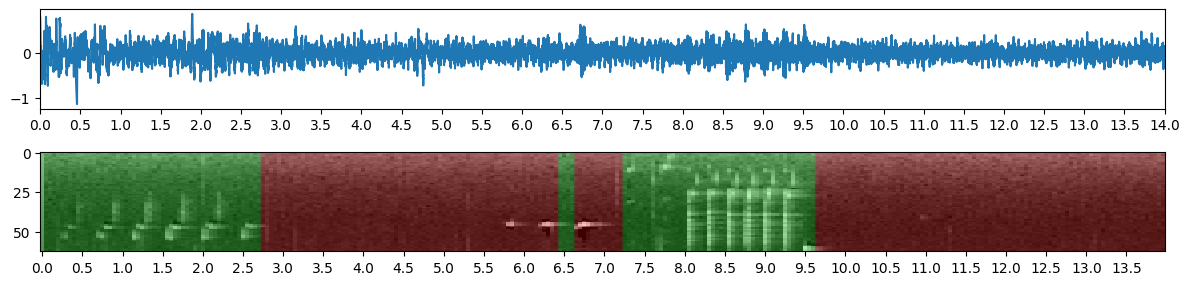

In [14]:
# analyse segmentation

# wbrtcvad - ne fonctionne pas vraiment
# config.preprocess.clip_sampling_rate_hz = 16000

def cluster_1level(spectrogram_db_df_l0, spectrogram_db_df_l1, NUM_CLUSTERS):
    # 1 clustering avec threshold sur energie

    # clustoriser pour marquer segments d'interets
    spectrogram_db_l0_kmeans, \
        spectrogram_db_std_df_l0 = kmeans_l0(spectrogram_db_df_l0,
                                             NUM_CLUSTERS)

    return clusters_to_mask(spectrogram_db_l0_kmeans.labels_,
                            spectrogram_db_l0_kmeans,
                            spectrogram_db_df_l1["energy"])

def cluster_1level_scores(spectrogram_db_df_l0, spectrogram_db_df_l1, NUM_CLUSTERS):
    # se servir du cluster_scores pour filtrer lesdits clusters - pas tout a fait ok
    # puisque cluster est peut-etre bon mais ne dit pas si noise ou chant
    # clustoriser pour marquer segments d'interets
    spectrogram_db_l0_kmeans, \
        spectrogram_db_std_df_l0 = kmeans_l0(spectrogram_db_df_l0,
                                             NUM_CLUSTERS)

    cluster_scores = clusters_analysis(spectrogram_db_std_df_l0,
                                       spectrogram_db_l0_kmeans.labels_)

    segmentation_mask = clusters_to_mask2(spectrogram_db_l0_kmeans,
                                          spectrogram_db_df_l1["energy"],
                                          cluster_scores)

def cluster_2levels(spectrogram_db_df_l0, spectrogram_db_df_l1, NUM_CLUSTERS):
    # 2 niveaux de clustring - marche pas comme idee mais donne meilleurs
    # resultats que 1 clsuter avec threshold sur energie
    # idee est de jumeler les clusters de premier niveau avec d'autres features
    # et de garder seulement 2 clusters

    # clustoriser pour marquer segments d'interets
    spectrogram_db_l0_kmeans, \
        spectrogram_db_std_df_l0 = kmeans_l0(spectrogram_db_df_l0,
                                             NUM_CLUSTERS)

    spectrogram_db_l1_kmeans, \
        features_l1, \
        features_std_l1 = kmeans_l1(spectrogram_db_l0_kmeans,
                                    spectrogram_db_df_l1)

    cluster_scores = clusters_analysis(features_std_l1,
                                       spectrogram_db_l1_kmeans.labels_)

    new_l0_labels = kmeans_l0_to_l1(spectrogram_db_l0_kmeans,
                                    spectrogram_db_l1_kmeans)

    return clusters_to_mask(new_l0_labels,
                            spectrogram_db_l1_kmeans,
                            features_l1["energy"])

def cluster_automatique(spectrogram_db_df_l0,
                        spectrogram_db_df_l1,
                        NUM_CLUSTERS,
                        segment_duration,
                        config):
    # 1 clustering par segments et threshold sur skewness energie

    print("NUM_CLUSTERS:", NUM_CLUSTERS, "segment_duration:", segment_duration)

    num_frames = int(segment_duration / config.spectrogram_stft_frame_size_ms)
    segments = rosa.util.frame(spectrogram_db_df_l0.T,
                               frame_length=num_frames,
                               hop_length=num_frames)

    mask = np.empty(spectrogram_db_df_l0.shape[0], dtype=int)
    mask[:] = -1
    clusters_df = None
    num_clusters = 0

    for s, f in enumerate(range(segments.shape[-1])):
        kmeans_data_df = pd.DataFrame(segments[..., f].T,
                                      index=range(num_frames),
                                      columns=spectrogram_db_df_l0.columns)
        kmeans_, _ = kmeans_l0(kmeans_data_df, NUM_CLUSTERS)
        base_index = s * num_frames

        for k in range( len(kmeans_.cluster_centers_) ):
            centroid = kmeans_.cluster_centers_[k]
            centroid = rosa.db_to_power(centroid)
            assert np.any( centroid <= 0) == False

            indices = np.argwhere( kmeans_.labels_ == k ).flatten() + base_index
            if len(indices) == 0:
                continue

            data = spectrogram_db_df_l1["energy"][indices]

            qs = np.quantile(data, q=[0.25, 0.5, 0.75])

            cluster_df = pd.DataFrame({
                "mean": [np.mean(data)],
                "std": [np.std(data)],
                "skew_sp": [sp.stats.skew(data)],
                "skew_iqr": [(qs[2] - qs[1]) / (qs[1] - qs[0] + 1e-10)],
                "flatness": sp.stats.gmean(centroid) / np.mean(centroid),
            })

            if clusters_df is None:
                clusters_df = cluster_df
            else:
                clusters_df = pd.concat([clusters_df, cluster_df], axis=0, ignore_index=True)

            mask[indices] = num_clusters
            num_clusters += 1

    return mask, clusters_df

def power_median_threshold(spectrogram_power, scale=5):
    spectrogram_power_med = sp.ndimage.median_filter(spectrogram_power, (5, 5))

    mask = spectrogram_power > (scale * spectrogram_power_med)
    mask = sp.ndimage.grey_closing(mask, (11, 11))
    mask = sp.ndimage.grey_erosion(mask, (5, 5))

    return np.any(mask, axis=0)

def plot_segmentation(path,
                      start_ms=None,
                      stop_ms=None,
                      alpha=0.25):
    # loading + features
    if True:
        wave_filename = Path.joinpath(config.paths.DATA_DIR, "audio", f"{path}.ogg")
        print(wave_filename)

        waveform, sr = rosa.load(wave_filename,
                                 sr=config.preprocess.clip_sampling_rate_hz)

        if start_ms is None:
            start_ms = 0

        if stop_ms is None:
            stop_ms = len(waveform) * sr * 1000

        start_s = start_ms / 1000
        stop_s = stop_ms / 1000
        wave_start = int(start_s * sr)
        wave_stop = int(stop_s * sr)
        waveform = waveform[wave_start:wave_stop]

        # normalize waveform [-1, 1]
        waveform *= 2.0 / (np.max(waveform) - np.min(waveform))

        # spectrogram du waveform
        spectrogram_db = spectrogram_from_audio(waveform,
                                                sr,
                                                config.preprocess,
                                                normalize_spectrogram=False)

        # recuperer la partie du spectrogram qui correspond aux frequences d'interet
        freqs = rosa.mel_frequencies(n_mels=config.preprocess.spectrogram_n_mels,
                                     fmin=config.preprocess.spectrogram_fmin,
                                     fmax=config.preprocess.spectrogram_fmax)
        freqs_low_index = np.argwhere(freqs >= 1_000)[0][0]
        freqs_high_index = np.argwhere(freqs <= 9_000)[-1][0]
        spectrogram_db = spectrogram_db[ freqs_low_index:freqs_high_index, :]
        spectrogram_power = rosa.db_to_power(spectrogram_db)

        # colliger en dataframe
        features = spectrogram_db.T
        spectrogram_db_df_l0 = pd.DataFrame(features,
                                            index=range(features.shape[0]),
                                            columns=[f"spectrogram_{c}" for c in range(features.shape[1])])

        # autre features
        spectrogram_db_df_l1 = pd.DataFrame()
        spectrogram_db_df_l1["energy"] = np.sum( spectrogram_power, axis=0 )
        spectrogram_db_df_l1["bandwidth"] = rosa.feature.spectral_bandwidth(S=spectrogram_power).flatten()
        spectrogram_db_df_l1["centroid"] = rosa.feature.spectral_centroid(S=spectrogram_power).flatten()

    segmentation_mask = None
    segmentation_image = None
    mask_df = None

    NUM_CLUSTERS = 15

    if False:
        segmentation_mask = cluster_2levels(spectrogram_db_df_l0,
                                            spectrogram_db_df_l1,
                                            NUM_CLUSTERS)
    elif False:
        segmentation_mask = cluster_1level(spectrogram_db_df_l0,
                                           spectrogram_db_df_l1,
                                           NUM_CLUSTERS)
    elif False:
        segmentation_mask = cluster_1level_scores(spectrogram_db_df_l0,
                                                  spectrogram_db_df_l1,
                                                  NUM_CLUSTERS)
    elif False:
        # examiner les features de spectrogram_db_df_l1
        spectrogram_db = spectrogram_db_df_l1.iloc[:, 2:3].T
    elif False:
        segmentation_mask, mask_df = cluster_automatique(spectrogram_db_df_l0,
                                                         spectrogram_db_df_l1,
                                                         3, # clusters
                                                         2_000, # duree segment pour cluster
                                                         config.preprocess)
    elif True:
        segmentation_mask = power_median_threshold(spectrogram_power, 5)
        print( segmentation_mask.dtype, segmentation_mask.shape )
    else:
        # # webrt vad - ne fonctionne pas vraiment mais si c'etait le cas, faudrait 
        # # operer sur le waveform avec un sampling rate fixe...
        # vad = wrtc.Vad(3)

        # num_samples = int(10 / 1000 * sr + 0.5)
        # frames = rosa.util.frame(waveform,
        #                          frame_length=num_samples,
        #                          hop_length=num_samples)

        # segmentation_mask = np.zeros(frames.shape[-1], dtype=np.bool_)

        # for f in range(frames.shape[-1]):
        #     frame = frames[..., f]
        #     frame = np.int16(frame * 32767)
        #     segmentation_mask[f] = vad.is_speech(frame.tobytes(), sr)
        pass

    if not segmentation_mask is None:
        segmentation_image = colorize_mask(segmentation_mask,
                                           spectrogram_db.shape[0])

    # affichage des resultats
    if True:
        fig = plt.figure(figsize=(12, 7))

        # afficher player audio
        display( Audio(data=waveform, rate=sr) )

        start_s = 0

        plt.subplot(511)
        waveform_show(waveform,
                      sr,
                      start_s=start_s)

        plt.subplot(512)
        specshow(spectrogram_db,
                 start_s=start_s,
                 preprocess_config=config.preprocess)
        if not segmentation_image is None:
            plt.imshow(segmentation_image,
                       aspect="auto",
                       alpha=alpha)

        if not mask_df is None:
            non_minus = np.argwhere(segmentation_mask != -1).flatten()

            plt.subplot(513)
            # plt.plot(mask_df["mean"], label="mean")
            # plt.plot(mask_df["std"], label="std")
            # plt.plot(mask_df["skew_sp"], label="skew_sp")
            # plt.plot(mask_df["skew_iqr"], label="skew_iqr")
            # plt.plot(mask_df["trace"], label="trace")
            plt.plot(non_minus,
                     mask_df["skew_iqr"][segmentation_mask[non_minus]],
                     label="skew_iqr")
            plt.xlim(0, len(segmentation_mask))
            plt.legend()
            # print(mask_df.shape, mask_df["trace"][segmentation_mask].shape)
            pass

        plt.tight_layout()
        plt.show()

plot_segmentation("thrnig1/XC494880", 21_000, 35_000) # pattern mince, beaucoup de bruit

# les interessants
# plot_segmentation("thrnig1/XC494880", 11_700, 21_700)
# plot_segmentation("thrnig1/XC494880", 10_000, 30_000)
# plot_segmentation("barswa/XC370786", 4_500, 13_500)
# plot_segmentation("barswa/XC370786", 0, None)
# plot_segmentation("combuz1/XC42427", 10_000, 20_000) # relativement simple

/Users/jfgagnon/Projects/FeatheredFury/data/audio/thrnig1/XC25663.ogg
bool (310,)


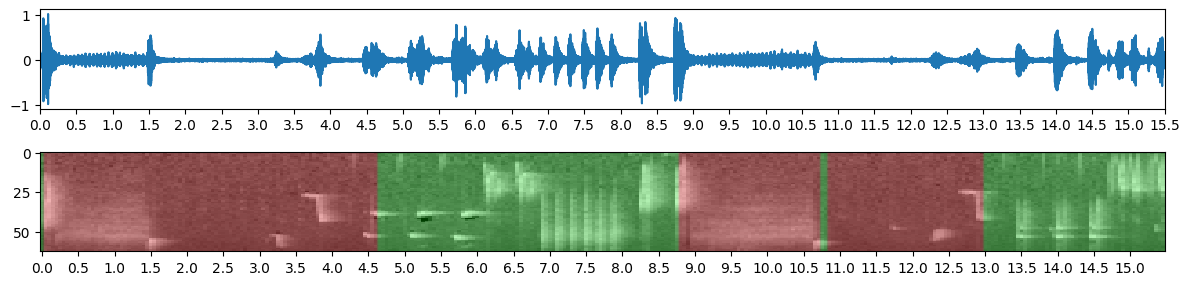

In [16]:
# plot_segmentation("thrnig1/XC25663", 0, None)
# plot_segmentation("thrnig1/XC25663", 0, 7_000)
# plot_segmentation("thrnig1/XC25663", 15_000, 22_000)
plot_segmentation("thrnig1/XC25663", 34_500, 50_000)

# plot_segmentation("barswa/XC187796", 65_000, 90_000) # simple
# plot_segmentation("barswa/XC187796", 9_500, 25_000)

# plot_segmentation("thrnig1/XC494880", 21_000, 35_000) # pattern mince, beaucoup de bruit
# plot_segmentation("thrnig1/XC494880", 17_500, 41_500)
# plot_segmentation("thrnig1/XC494880", 18_000, 24_000)
# plot_segmentation("thrnig1/XC396432", 0_000, 10_000)


# les interessants
# plot_segmentation("thrnig1/XC494880", 11_700, 21_700)
# plot_segmentation("thrnig1/XC494880", 10_000, 20_000)
# plot_segmentation("barswa/XC370786", 4_500, 13_500)
# plot_segmentation("combuz1/XC42427", 10_000, 20_000) # relativement simple

In [ ]:
# # test sur sample aleatoire

# filename = np.random.choice(train_data_df)
# filename = Path(filename).with_suffix("")
# plot_segmentation(filename, 0, None)